In [1]:
# Imports
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize


In [2]:
# # Load and save dataset from video
# # Variables
# video_path = "data/input_videos/grasrobot.mp4"
# image_path = "data/divers1/"
# amount_of_frames = 100

# # Extract frames
# video = cv2.VideoCapture(video_path)
# frame_count = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
# frame_interval = int(frame_count/(amount_of_frames-1)) # -1 since frames start at 0
# current_frame = 0

# # Loop through every frame
# while True:
#     read, frame = video.read()
#     if not read:
#         break # if no frame read, end of video
#     if current_frame % frame_interval == 0:
#         img_name = os.path.join(image_path, f"frame_{current_frame:04d}.jpg")
#         cv2.imwrite(img_name, frame)
#         print(f"Saved frame {current_frame}")
#     current_frame += 1

# # Release video capture object
# video.release()
# print(f"All frames have been saved to {image_path}")

In [3]:
# Load functions
def preprocess_image(image):
        preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
                             ])
        return preprocess(image)

def load_img(img_path, target_size=None):
    """
    Load and optionally resize image.
    """
    img = Image.open(img_path)
    if target_size:
        img = img.resize(target_size)
    return np.array(img)


def visualize_embedding(embedding, frames_path, prune_mask=None):
    """
    Visualizes image embeddings, maintaining their position even after pruning.

    Parameters:
    - embedding: 2D numpy array
    - prune_mask: Boolean mask of shape (N,) indicating which images to keep
    """

    plt.figure(figsize=(10, 8))

    if prune_mask is None:
        prune_mask = np.ones(len(embedding), dtype=bool)
    
    frames = os.listdir(frames_path)
    pruned_embedding = embedding[prune_mask]
    pruned_frames = np.array(frames)[prune_mask]

    for idx, frame in enumerate(pruned_embedding):
        x, y = frame[0], frame[1]
        plt.scatter(x, y, alpha=0)

        img_path = os.path.join(frames_path, pruned_frames[idx])
        img = load_img(img_path=img_path, target_size=(50, 50))
        imagebox = OffsetImage(img, zoom=0.8)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False, pad=0.1)
        plt.gca().add_artist(ab)
    
    plt.title("Embedding space")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.autoscale(True)
    plt.grid()
    plt.show()

In [4]:
try:
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
    model = torch.nn.Sequential(*(list(model.children())[:-1]))
    print("Pretrained ResNet50 (ImageNet) loaded successfully")
except Exception as e:
    print(f"Error loading ResNet50: {e}")

model.eval()

Pretrained ResNet50 (ImageNet) loaded successfully


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [5]:
frames = os.listdir("data/divers1/")
embeddings = []

for _, frame in enumerate(frames):
    img = Image.open("data/divers1/" + frame)
    preprocessed_img = preprocess_image(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features = model(input_tensor)
    embeddings.append(features.flatten())
    
embedding1 = np.array(embeddings)
embedding1_norm = normalize(embedding1, axis=1)


In [6]:
# Load ResNet50-model
num_classes = 1081
resnet_checkpoint_path = 'models/pretrained/resnet50_weights_best_acc.tar'

try:
    model = resnet50(num_classes=num_classes)
    model = torch.nn.Sequential(*(list(model.children())[:-1]))
    checkpoint = torch.load(resnet_checkpoint_path, map_location='cpu', weights_only=True)
    state_dict = checkpoint.get('state_dict', checkpoint)
    model.load_state_dict(state_dict=state_dict, strict=False)
    print("ResNet loaded succesfully")
except Exception as e:
    print(f"Error loading ResNet: {e}")

model.eval()

ResNet loaded succesfully


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [7]:
frames = os.listdir("data/divers1/")
embeddings = []

for _, frame in enumerate(frames):
    img = Image.open("data/divers1/" + frame)
    preprocessed_img = preprocess_image(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features = model(input_tensor)
    embeddings.append(features.flatten())
    
embedding2 = np.array(embeddings)
embedding2_norm = normalize(embedding2, axis=1)

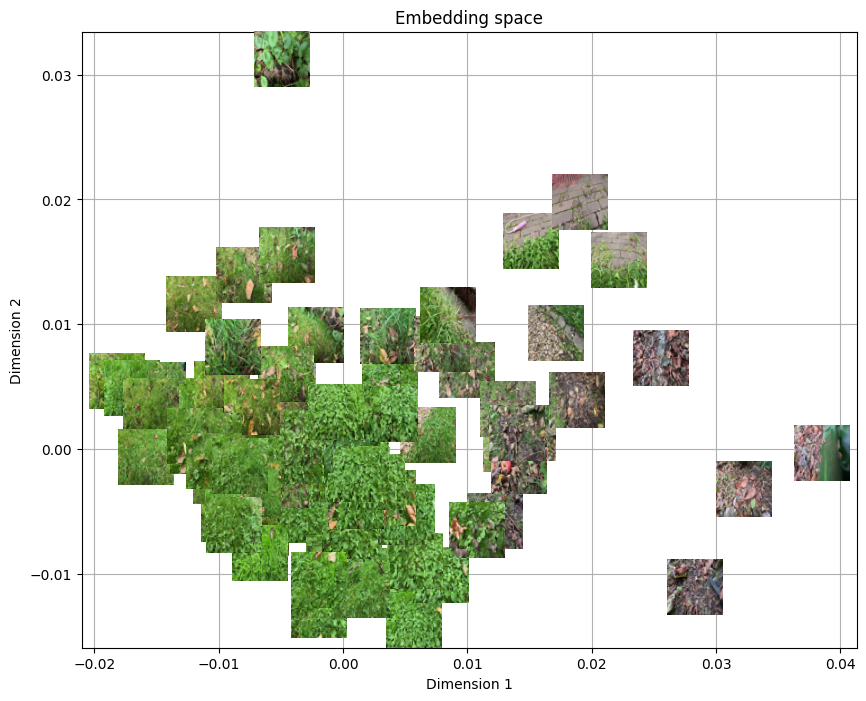

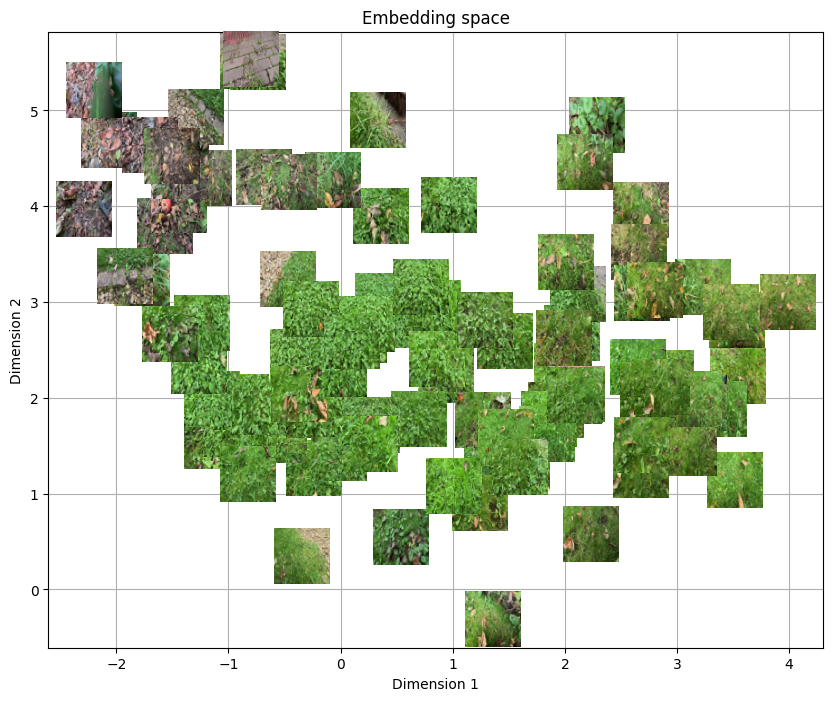

In [10]:
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(embedding2_norm)
visualize_embedding(embedding=pca_results, frames_path="data/divers1/")


tsne = TSNE(n_components=2, perplexity=50, random_state=42)
tsne_results = tsne.fit_transform(embedding2_norm)
visualize_embedding(embedding=tsne_results, frames_path="data/divers1/")

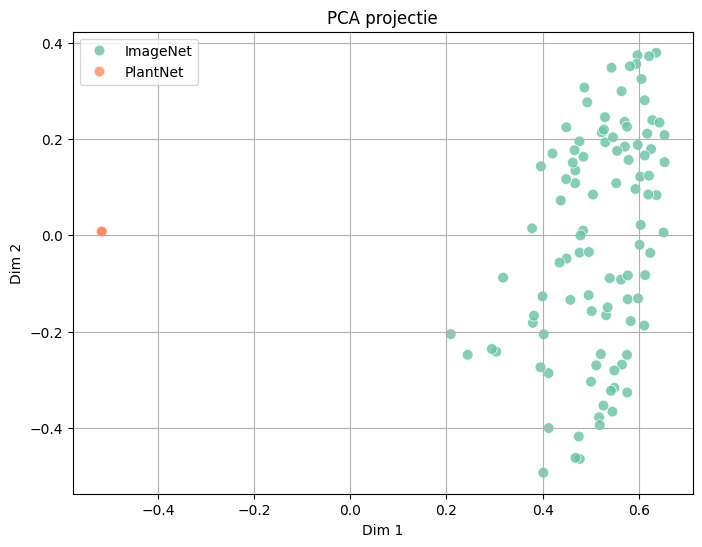

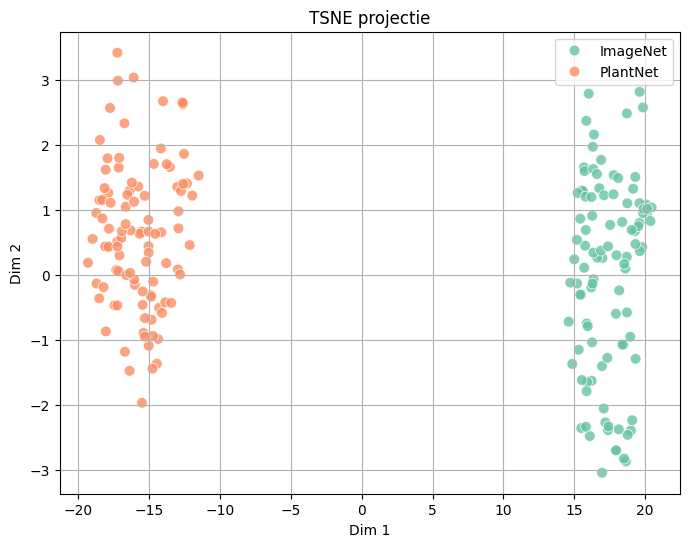

In [9]:
def plot_embedding(X_proj, labels, title):
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_proj[:, 0], y=X_proj[:, 1], hue=labels, palette='Set2', s=60, alpha=0.8)
    plt.title(title)
    plt.xlabel('Dim 1')
    plt.ylabel('Dim 2')
    plt.legend()
    plt.grid(True)
    plt.show()


combined = np.vstack([embedding1_norm, embedding2_norm])
labels = np.array(['ImageNet'] * len(embedding1_norm) + ['PlantNet'] * len(embedding2_norm))

pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(combined)
plot_embedding(pca_results, labels, "PCA projectie")

tsne = TSNE(n_components=2, perplexity=50, random_state=42)
tsne_results = tsne.fit_transform(combined)
plot_embedding(tsne_results, labels, "TSNE projectie")